# Electricity demand forecasting — complete CRISP-DM lifecycle

This notebook executes the revised project from business understanding to local delivery. It preserves the earlier study as version 1 and uses a fresh 2026 test. Run cells in order. SQL and Python helpers contain explanatory code-block comments; methodology and decisions are documented alongside the outputs.

In [1]:
# Setup: locate the repository and import reusable, side-effect-free analysis helpers.
# Importing run_lifecycle defines functions but does not launch the experiment.
import sys
from pathlib import Path
project=Path.cwd()
if project.name=='notebooks': project=project.parent
sys.path.insert(0,str(project/'scripts'))
from run_lifecycle import *
from IPython.display import display, Image


## 1. Business understanding

Read the protocol first: stakeholder assumptions, energy-volume decisions, proposed 10% MAE-improvement and <3% bias gates. These criteria are analyst-proposed. The fresh test has not been used to tune this revision.

In [2]:
stage('PHASE 1/6 | BUSINESS UNDERSTANDING: read fixed protocol and proposed acceptance criteria')
protocol=ROOT/'docs/EXPERIMENT_PROTOCOL_V2.md'
print('Protocol:',protocol,flush=True)
protocol_hash=hashlib.sha256(protocol.read_bytes()).hexdigest()




PHASE 1/6 | BUSINESS UNDERSTANDING: read fixed protocol and proposed acceptance criteria


Protocol: <project-root>/docs/EXPERIMENT_PROTOCOL_V2.md


## 2–3. Data understanding and preparation

Validate source keys, units and date coverage; preserve unknown targets through SQL calendar joins. Inspect development-only distributions and flag outliers without deleting grid events. See the data dictionary and cleaning log. The code executes the actual curation and EDA.

In [3]:
# PHASES 2–3 — Validate and integrate data; characterize development data only.
stage('PHASE 2/6 | DATA UNDERSTANDING: schema, units, missingness, revisions and SQL joins')
df=prepare()
stage('PHASE 3/6 | PREPARATION: retain unknown targets; flag unusual values without deletion')
dev=df.loc[:'2023-12-31'].copy()
dev.describe(percentiles=[.01,.05,.5,.95,.99]).to_csv(R/'development_distribution.csv')
median=dev.demand_mwh.rolling(28,min_periods=14).median().shift(1)
deviation=(dev.demand_mwh-median).abs()
robust_scale=deviation.rolling(56,min_periods=28).median().shift(1)*1.4826
flagged=dev[deviation>6*robust_scale].copy()
flagged['reason']='more than six rolling robust scales from prior median; retained'
flagged.to_csv(R/'development_outlier_flags.csv')
fig,axes=plt.subplots(2,2,figsize=(13,8))
axes[0,0].plot(dev.index,dev.demand_mwh/1e6,lw=.7);axes[0,0].set(title='Development demand only (2019–2023)',ylabel='Million MWh')
dev.demand_mwh.div(1e6).hist(bins=35,ax=axes[0,1],color='#167d9a');axes[0,1].set(title='Demand distribution',xlabel='Million MWh')
axes[1,0].scatter(dev.temp,dev.demand_mwh/1e6,s=5,alpha=.3);axes[1,0].set(title='Weather association',xlabel='Temperature °C',ylabel='Million MWh')
dev.groupby(dev.index.month).demand_mwh.mean().div(1e6).plot.bar(ax=axes[1,1],color='#167d9a');axes[1,1].set(title='Seasonal pattern',xlabel='Month',ylabel='Mean million MWh/day')
fig.tight_layout();fig.savefig(F/'01_data_understanding.png',dpi=150);plt.close(fig)
acf=pd.DataFrame({'lag_days':range(1,61),'demand_autocorrelation':[dev.demand_mwh.autocorr(i) for i in range(1,61)]})
acf.to_csv(R/'development_autocorrelation.csv',index=False)




PHASE 2/6 | DATA UNDERSTANDING: schema, units, missingness, revisions and SQL joins


year  days_in_snapshot  observed_demand_days  missing_demand_days  incomplete_weather_days
2019               365                   365                    0                        0
2020               366                   366                    0                        0
2021               365                   365                    0                        0
2022               365                   365                    0                        0
2023               365                   365                    0                        0
2024               366                   366                    0                        0
2025               365                   364                    1                        0
2026               243                   243                    0                        0


Data audit: {"retrieved": "2026-09-28", "dates": 2800, "observed_demand": 2799, "missing_demand_dates": ["2025-12-05"], "overlap_revisions": 0, "raw_sha256": {"weather.json": "83674c6a0f63565bd579384b8bedbdc7f331fba62df0389c3a79c363c8e2edc3", "eia.json": "fb18de6e9a1f1a05211e557292ad8de7ddeefa4ab5c14aee9c0ddb9c432440d4"}}



PHASE 3/6 | PREPARATION: retain unknown targets; flag unusual values without deletion


,year,days_in_snapshot,observed_demand_days,missing_demand_days,incomplete_weather_days
0,2019,365,365,0,0
1,2020,366,366,0,0
2,2021,365,365,0,0
3,2022,365,365,0,0
4,2023,365,365,0,0
5,2024,366,366,0,0
6,2025,365,364,1,0
7,2026,243,243,0,0


,date,field,action,reason
0,2025-12-05,demand_mwh,retain NULL; exclude target from scoring,missing target


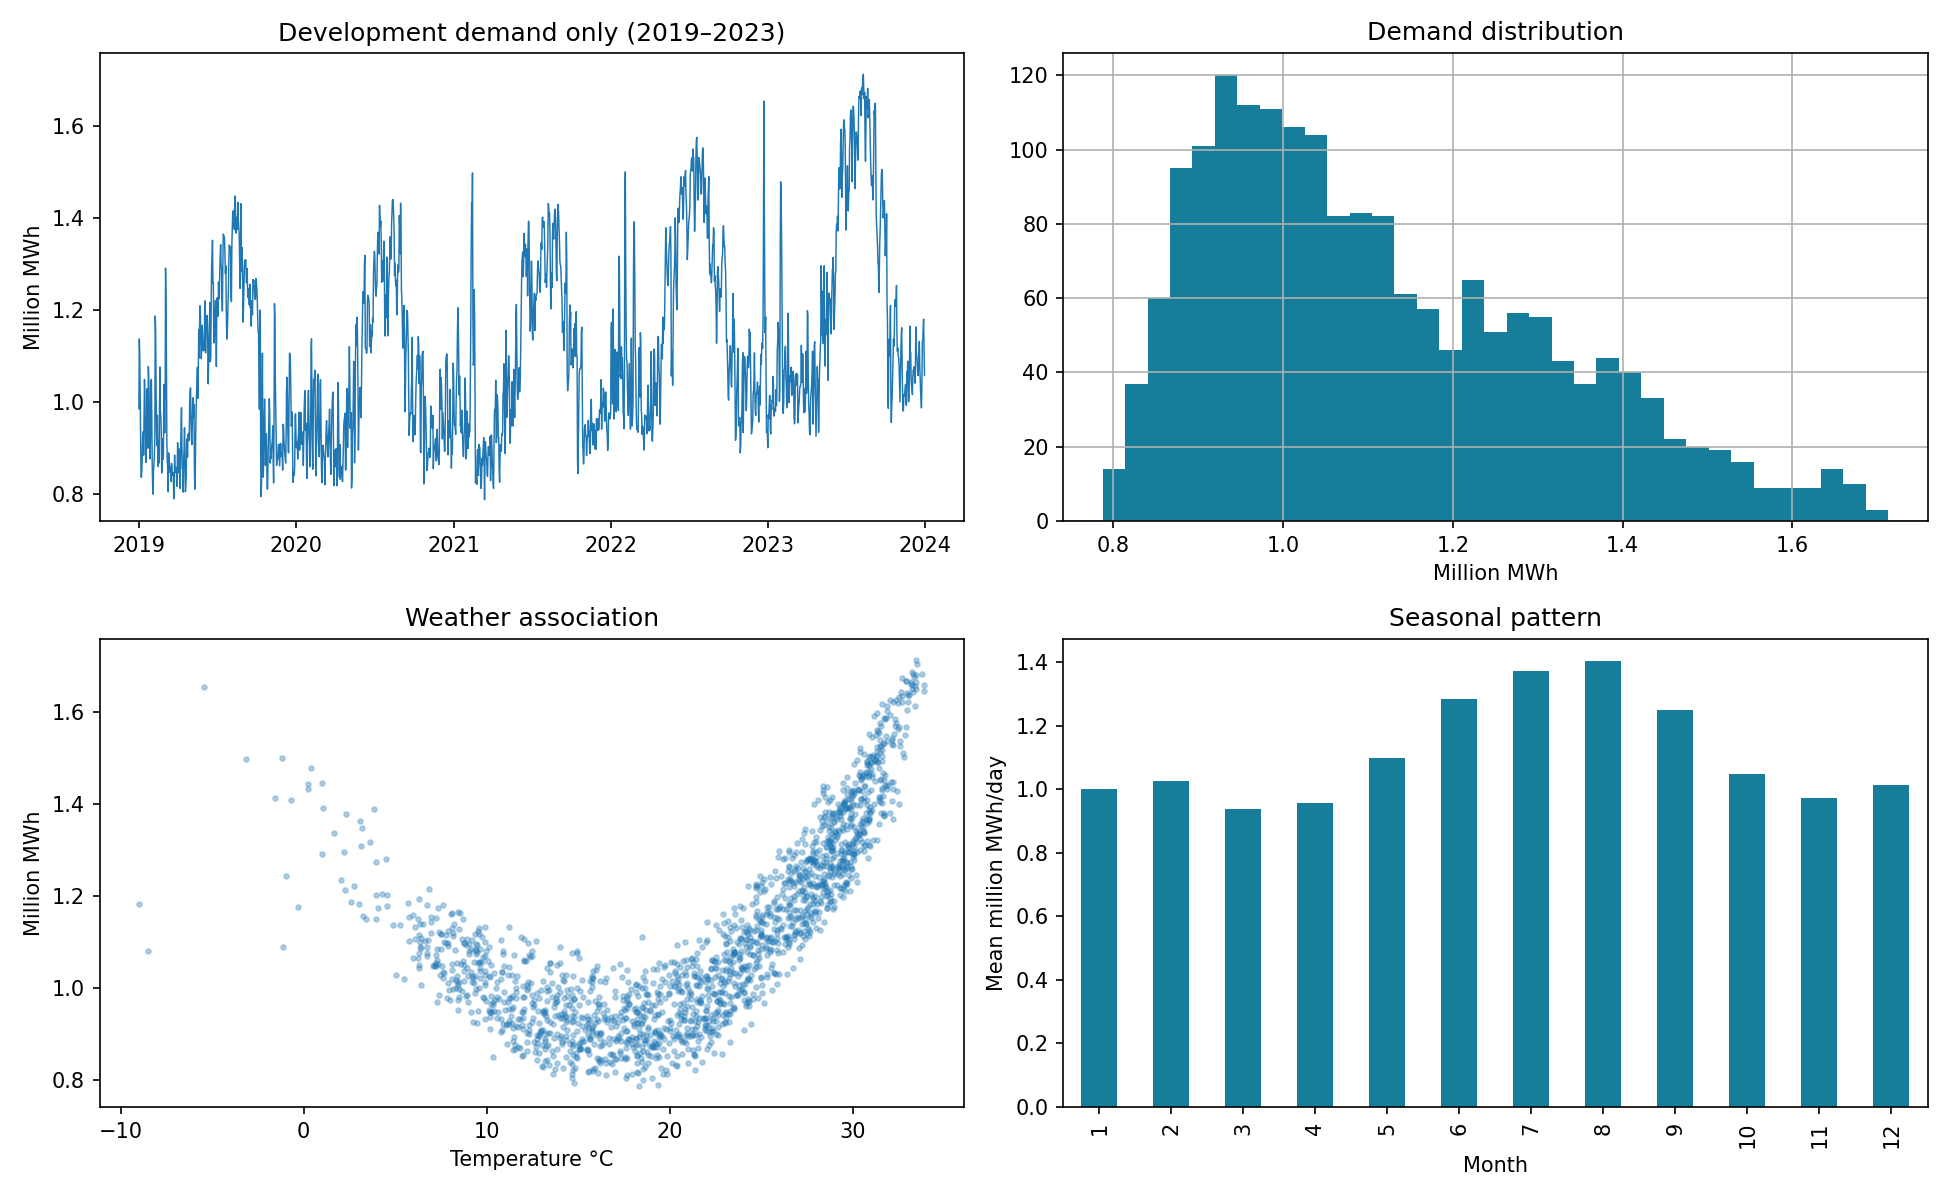

In [4]:
# Inspect real SQL quality results and the data-understanding figure.
display(pd.read_csv(R/'yearly_quality.csv'))
display(pd.read_csv(R/'cleaning_log.csv'))
display(Image(filename=str(F/'01_data_understanding.png')))


## 4. Modeling and temporal validation

Fit two expanding development folds, compare baselines and six candidates, and freeze scale-specific winners. All imputers/scalers are training-fitted. Features use issue−1 demand and issue−7 weather. A later 2024 check does not change selection. This cell trains the models and prints progress.

In [5]:
# PHASE 4 — Tune only on two expanding development folds, then freeze winners.
stage('PHASE 4/6 | MODELING: expanding folds 2022 and 2023; no random split')
fold_metrics=[]; train_metrics=[]
for year in [2022,2023]:
    _,train,_,_,metrics=experiment(df,f'{year-1}-12-31',f'{year}-01-01',f'{year}-12-31')
    metrics['fold']=year; train['fold']=year
    baseline=metrics[metrics.model=='repeat_week'].set_index('scale').mae_mwh
    metrics['relative_mae']=metrics.mae_mwh/metrics.scale.map(baseline)
    fold_metrics.append(metrics);train_metrics.append(train)
folds=pd.concat(fold_metrics,ignore_index=True)
folds.to_csv(R/'cross_validation_metrics.csv',index=False)
training=pd.concat(train_metrics)
training.to_csv(R/'training_metrics.csv',index=False)
gaps=folds[folds.scale=='daily'].merge(training,on=['model','fold'],suffixes=('_validation','_training'))
gaps['validation_to_training_mae']=gaps.mae_mwh/gaps.training_daily_mae
gaps.to_csv(R/'train_validation_gap.csv',index=False)
ranking=folds.groupby(['scale','model']).agg(mean_relative_mae=('relative_mae','mean'),worst_relative_mae=('relative_mae','max')).reset_index()
ranking.to_csv(R/'candidate_ranking.csv',index=False)
winners=ranking.loc[ranking.groupby('scale').mean_relative_mae.idxmin()].set_index('scale').model.to_dict()
(R/'frozen_selection.json').write_text(json.dumps({'selection_folds':[2022,2023],'protocol_sha256':protocol_hash,'models':winners},indent=2)+'\n')
print('Frozen selections:',winners,flush=True)
print(ranking.round(3).to_string(index=False),flush=True)
_,_,_,_,check=experiment(df,'2023-12-31','2024-01-01','2024-12-31')
check.to_csv(R/'development_2024_metrics.csv',index=False)
print('2024 development check saved; choices remain frozen.',flush=True)




PHASE 4/6 | MODELING: expanding folds 2022 and 2023; no random split



    Fit ridge_1_calendar: 32,519 origin/target examples through 2021-12-31



    Fit ridge_1_weather: 32,519 origin/target examples through 2021-12-31



    Fit ridge_100_calendar: 32,519 origin/target examples through 2021-12-31



    Fit ridge_100_weather: 32,519 origin/target examples through 2021-12-31


...


    Fit ridge_100_calendar: 55,149 origin/target examples through 2023-12-31



    Fit ridge_100_weather: 55,149 origin/target examples through 2023-12-31



    Fit trees_calendar: 55,149 origin/target examples through 2023-12-31



    Fit trees_weather: 55,149 origin/target examples through 2023-12-31


2024 development check saved; choices remain frozen.


## 5. Calibration and fresh evaluation

Previously inspected 2025 is calibration, not a new holdout. Refit through 2025 and evaluate January–August 2026 only after selection. Weekly and monthly totals must come from one pre-period issue date. Missing actuals invalidate entire containing totals.

In [6]:
# PHASE 5 — Calibrate on previously inspected 2025, then open fresh 2026 test once.
stage('PHASE 5/6 | EVALUATION: 2025 interval calibration; fresh Jan–Aug 2026 final test')
_,_,_,calibration,_=experiment(df,'2024-12-31','2025-01-01','2025-12-31',set(winners.values()))
calibration.to_csv(R/'calibration_periods.csv',index=False)
widths={}
for scale,name in winners.items():
    c=calibration[calibration.scale==scale].dropna(subset=['actual',name])
    residual=np.sort(abs(c[name]-c.actual))
    widths[scale]=float(residual[min(len(residual)-1,int(np.ceil((len(residual)+1)*.9))-1)])
test_bundle,_,paths,periods,metrics=experiment(df,'2025-12-31','2026-01-01','2026-08-31')
paths.to_csv(R/'test_paths.csv',index=False);periods.to_csv(R/'test_periods.csv',index=False)
metrics.to_csv(R/'test_metrics.csv',index=False)
selected=[];summary=[]
for scale,name in winners.items():
    g=periods[periods.scale==scale].copy();g['model']=name;g['prediction']=g[name]
    g['lower90']=np.maximum(0,g.prediction-widths[scale]);g['upper90']=g.prediction+widths[scale]
    selected.append(g)
    row=metrics[(metrics.scale==scale)&(metrics.model==name)].iloc[0].to_dict()
    base=metrics[(metrics.scale==scale)&(metrics.model=='repeat_week')].iloc[0]
    row['improvement_pct']=100*(1-row['mae_mwh']/base.mae_mwh)
    observed=g.dropna(subset=['actual']); row['coverage_pct']=100*observed.actual.between(observed.lower90,observed.upper90).mean()
    row['proposed_gate_pass']=bool(row['improvement_pct']>=10 and abs(row['bias_pct'])<3)
    summary.append(row)
selected=pd.concat(selected,ignore_index=True);summary=pd.DataFrame(summary)
selected.to_csv(R/'selected_forecasts.csv',index=False);summary.to_csv(R/'management_scorecard.csv',index=False)
print('\nFRESH TEST SCORECARD\n'+summary.round(2).to_string(index=False),flush=True)




PHASE 5/6 | EVALUATION: 2025 interval calibration; fresh Jan–Aug 2026 final test



    Fit ridge_100_weather: 66,495 origin/target examples through 2024-12-31



    Fit ridge_1_calendar: 77,779 origin/target examples through 2025-12-31



    Fit ridge_1_weather: 77,779 origin/target examples through 2025-12-31



    Fit ridge_100_calendar: 77,779 origin/target examples through 2025-12-31



    Fit ridge_100_weather: 77,779 origin/target examples through 2025-12-31



    Fit trees_calendar: 77,779 origin/target examples through 2025-12-31



    Fit trees_weather: 77,779 origin/target examples through 2025-12-31



FRESH TEST SCORECARD
  scale             model   n    mae_mwh   rmse_mwh  wape_pct  bias_pct  improvement_pct  coverage_pct  proposed_gate_pass
  daily       persistence 243   74396.79  100118.69      5.26     -0.28            23.01         86.83                True
monthly ridge_100_weather   8 1058431.94 1393160.11      2.46     -0.97            57.69        100.00                True
 weekly       repeat_week  34  481088.15  649336.91      4.85     -1.38             0.00         97.06               False


## 5b. Diagnostics and interpretation

Examine residual slices, high demand, paired weather ablations and errors by lead on common origins. A block bootstrap is a descriptive stability check. These findings do not cause retuning on the test.

In [7]:
# PHASE 5b — Diagnose residual structure, difficult regimes and paired weather value.
# These diagnostics do not trigger another tuning cycle on the test.
daily=selected[selected.scale=='daily'].sort_values('start').copy()
daily['error']=daily.prediction-daily.actual
daily['month']=daily.start.dt.month;daily['weekday']=daily.start.dt.dayofweek
high_threshold=df.loc[:'2025-12-31'].demand_mwh.quantile(.9)
daily['demand_regime']=np.where(daily.actual>=high_threshold,'high (training p90)','normal')
slices=[]
for dimension in ['month','weekday','demand_regime']:
    for value,g in daily.groupby(dimension):
        g=g.dropna(subset=['actual'])
        slices.append({'dimension':dimension,'value':value,'n':len(g),'wape_pct':100*abs(g.error).sum()/g.actual.sum(),'bias_pct':100*g.error.sum()/g.actual.sum()})
pd.DataFrame(slices).to_csv(R/'residual_slices.csv',index=False)
pd.DataFrame({'lag':range(1,29),'residual_autocorrelation':[daily.error.autocorr(i) for i in range(1,29)]}).to_csv(R/'residual_autocorrelation.csv',index=False)
daily.assign(abs_error=lambda x:abs(x.error)).nlargest(10,'abs_error').to_csv(R/'largest_daily_misses.csv',index=False)
ablations=[]
for scale in ['daily','weekly','monthly']:
    for family in ['ridge_1','ridge_100','trees']:
        pair=metrics[(metrics.scale==scale)&metrics.model.isin([family+'_calendar',family+'_weather'])].set_index('model')
        ablations.append({'scale':scale,'family':family,'weather_mae_change_pct':100*(pair.loc[family+'_weather','mae_mwh']/pair.loc[family+'_calendar','mae_mwh']-1)})
pd.DataFrame(ablations).to_csv(R/'weather_ablation.csv',index=False)
# Compare leads on common origins, avoiding a different seasonal sample at each lead.
common=paths[(paths.origin+pd.Timedelta(days=31)<=pd.Timestamp('2026-08-31')) & (paths.target<=pd.Timestamp('2026-08-31'))]
leads=[]
for h,g in common.groupby('horizon'):
    g=g.dropna(subset=['actual',winners['daily']])
    leads.append({'lead':h,'n':len(g),'wape_pct':100*abs(g[winners['daily']]-g.actual).sum()/g.actual.sum()})
pd.DataFrame(leads).to_csv(R/'common_origin_lead_metrics.csv',index=False)
# Moving-block resampling retains short-range dependence better than shuffling individual days.
paired=(abs(daily.repeat_week-daily.actual)-abs(daily.prediction-daily.actual)).dropna().to_numpy()
rng=np.random.default_rng(42);means=[]
for _ in range(1000):
    starts=rng.integers(0,len(paired)-6,size=int(np.ceil(len(paired)/7)))
    sample=np.concatenate([paired[i:i+7] for i in starts])[:len(paired)]
    means.append(sample.mean())
stability={'mean_daily_mae_gain_mwh':float(paired.mean()),'block_bootstrap_95pct_mwh':np.quantile(means,[.025,.975]).tolist(),
    'block_days':7,'resamples':1000,'caution':'Descriptive stability interval, not proof across unseen regimes.'}
(R/'daily_gain_stability.json').write_text(json.dumps(stability,indent=2)+'\n')



255

## 5c. Visual evaluation

Inspect actual versus predicted demand and uncertainty. Residual structure can reveal unresolved patterns. The small monthly sample cannot prove calibration even with high measured coverage.

In [8]:
# PHASE 5c — Report measured uncertainty and show remaining forecast failures.
fig,axes=plt.subplots(3,1,figsize=(13,10))
for ax,scale in zip(axes,['daily','weekly','monthly']):
    g=selected[selected.scale==scale].sort_values('start')
    ax.plot(g.start,g.actual/1e6,label='Actual',color='#233447')
    ax.plot(g.start,g.prediction/1e6,label='Forecast',color='#d27031')
    ax.fill_between(g.start,g.lower90/1e6,g.upper90/1e6,color='#d27031',alpha=.15,label='Approx. 90% interval')
    ax.set(title=f'Fresh 2026 test • {scale} • {winners[scale]}',ylabel='Million MWh');ax.legend(fontsize=8)
fig.tight_layout();fig.savefig(F/'02_fresh_test.png',dpi=150);plt.close(fig)
fig,axes=plt.subplots(1,3,figsize=(14,4))
axes[0].plot(daily.start,daily.error/1e3);axes[0].axhline(0,color='black',lw=.7)
axes[0].set(title='Daily residuals: forecast − actual',ylabel='Thousand MWh')
from matplotlib.dates import MonthLocator, DateFormatter
axes[0].xaxis.set_major_locator(MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(DateFormatter('%b %Y'))
daily.error.div(1e3).hist(bins=25,ax=axes[1]);axes[1].set(title='Error distribution',xlabel='Thousand MWh')
axes[2].bar(range(1,29),[daily.error.autocorr(i) for i in range(1,29)]);axes[2].set(title='Residual autocorrelation',xlabel='Lag days')
fig.tight_layout();fig.savefig(F/'03_residual_diagnostics.png',dpi=150);plt.close(fig)



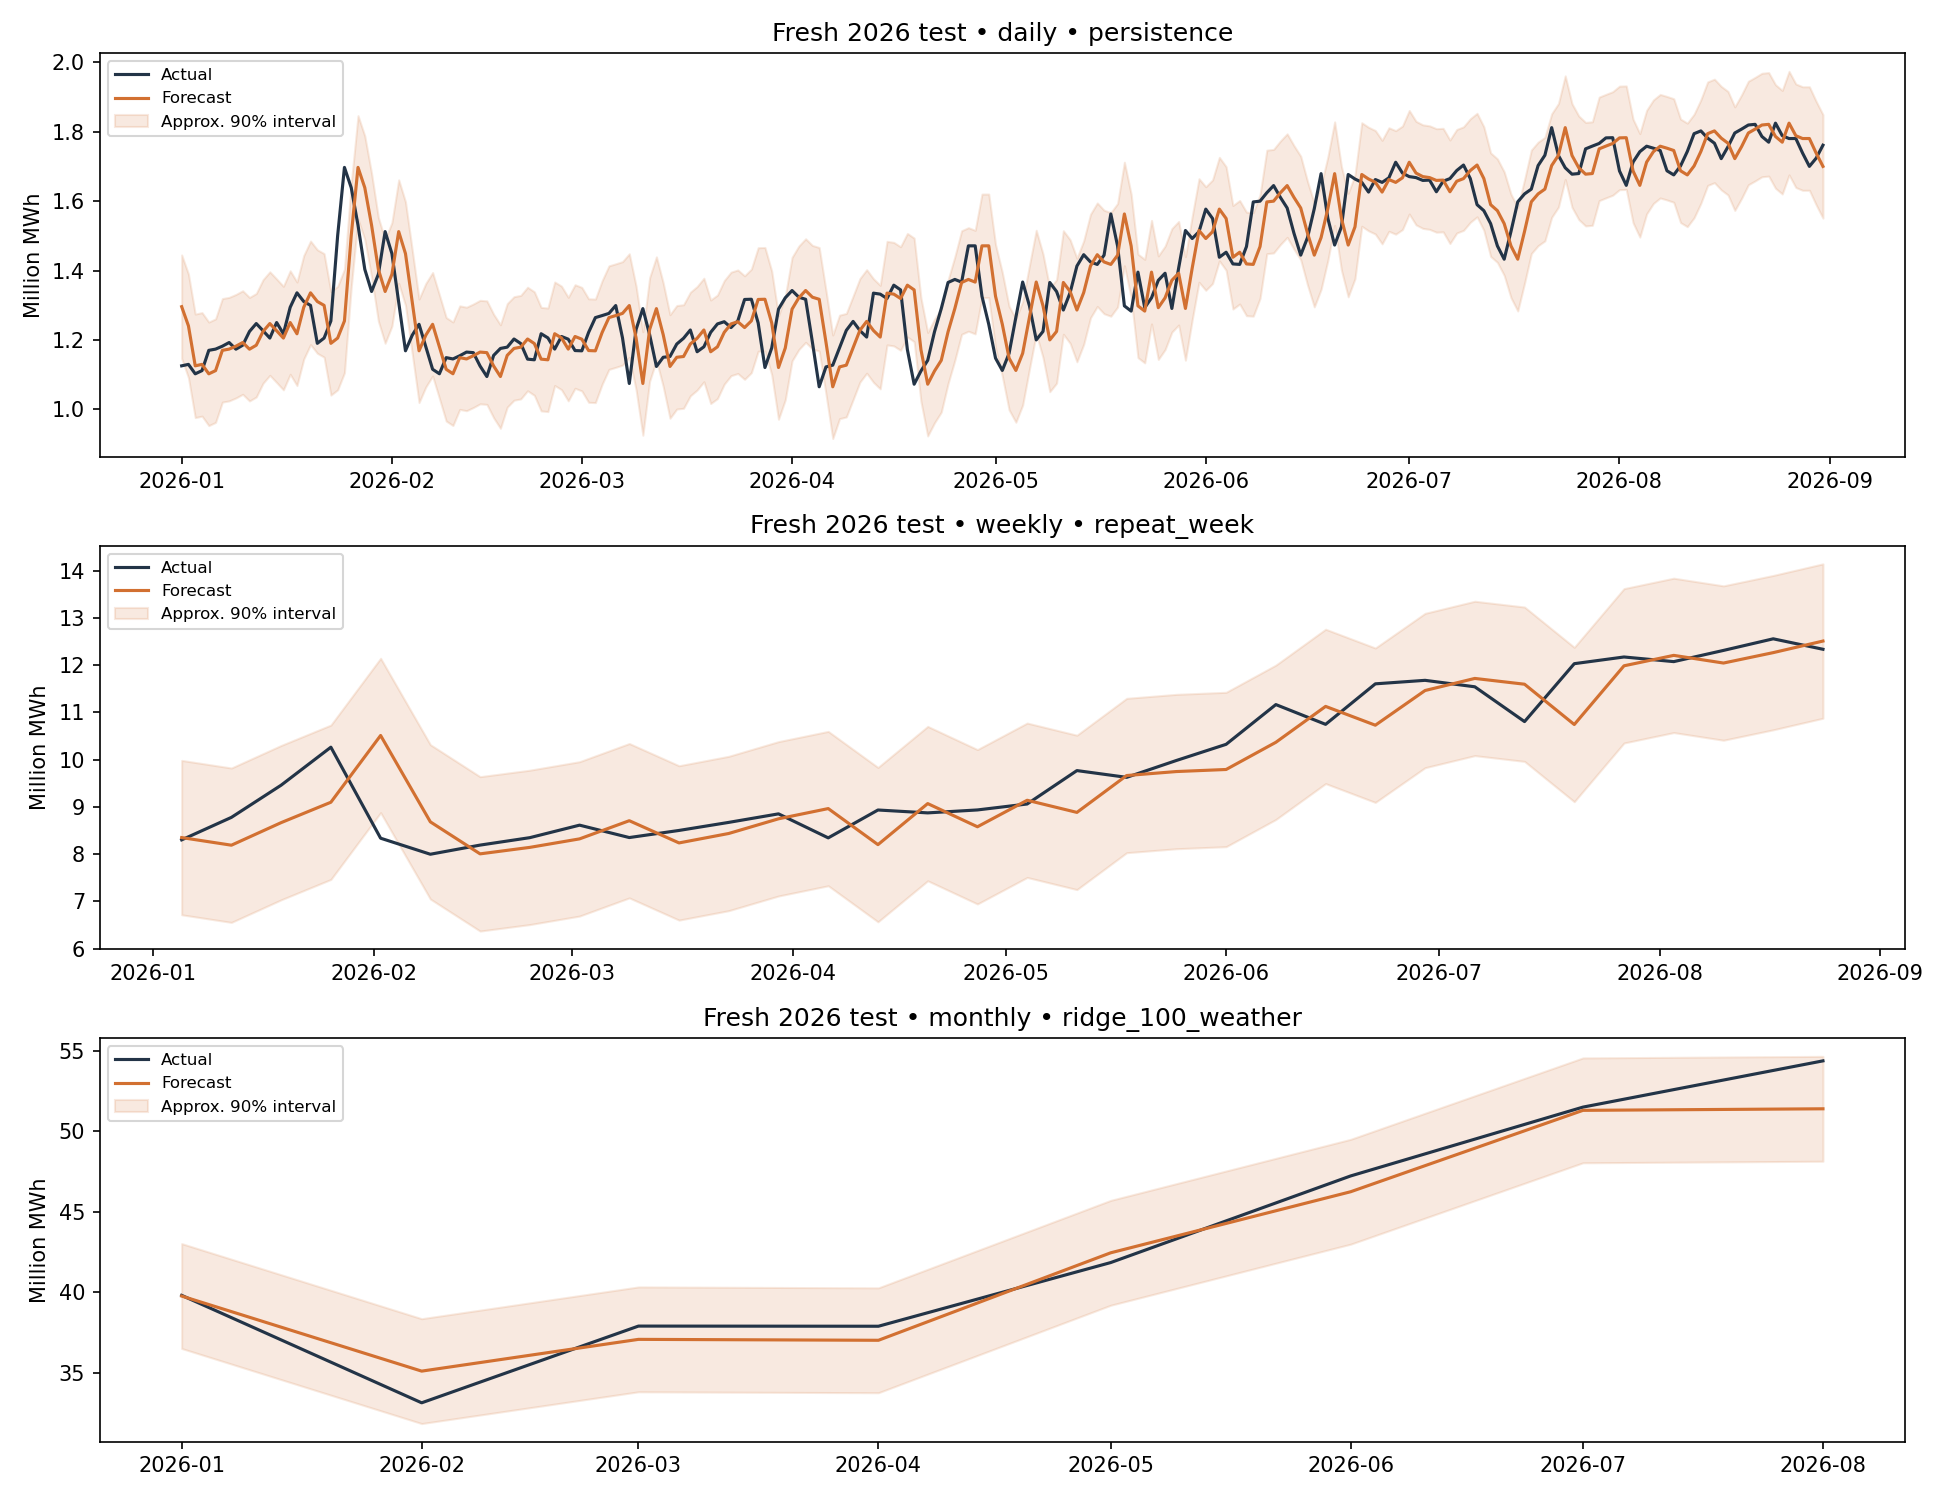

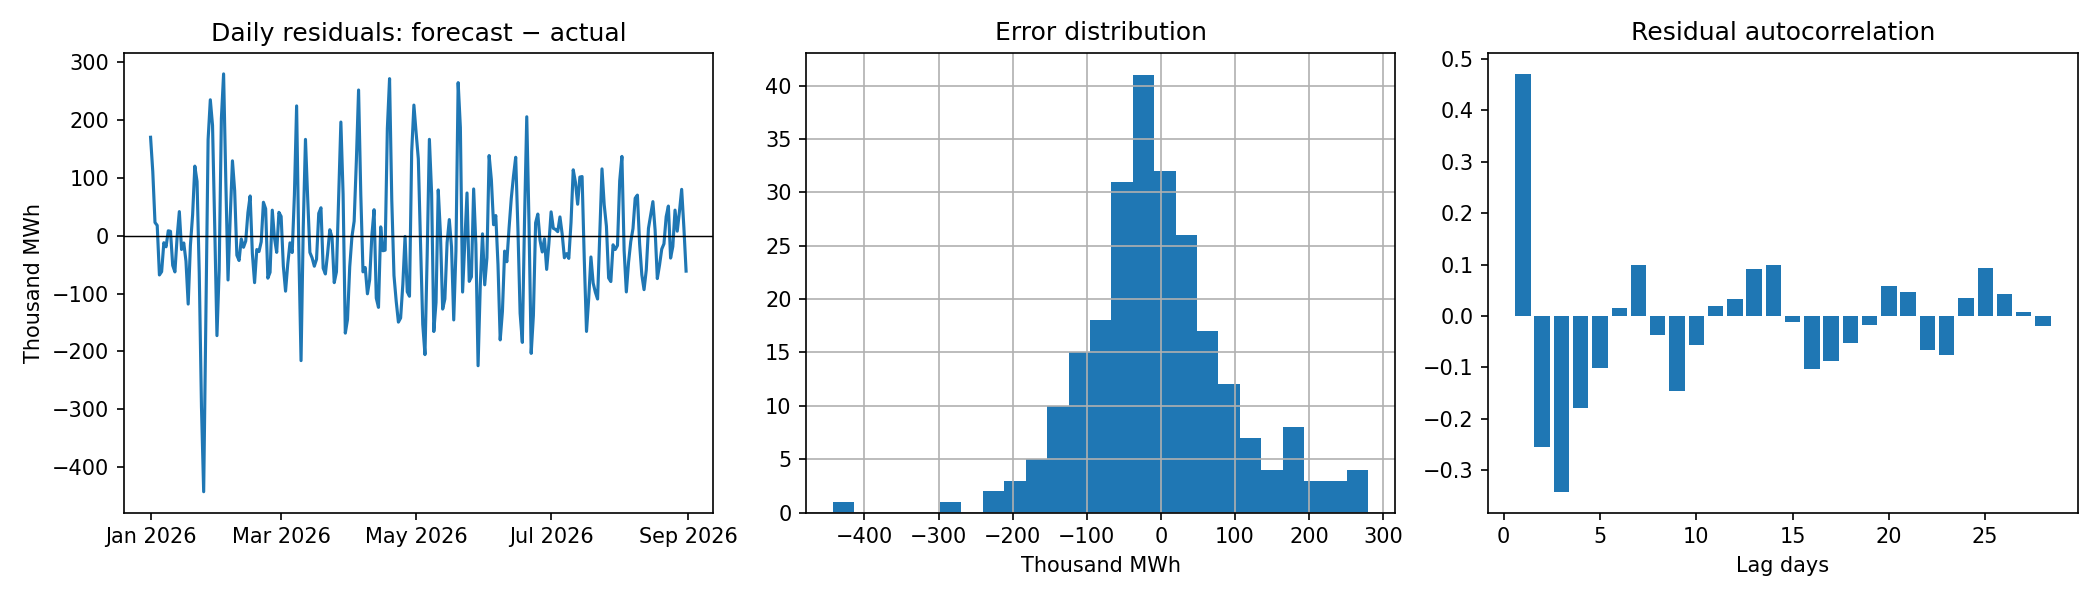

In [9]:
# Display saved plots to assess uncertainty and unresolved residual patterns.
display(Image(filename=str(F/'02_fresh_test.png')))
display(Image(filename=str(F/'03_residual_diagnostics.png')))


## 6. Delivery and monitoring

Refit the selected models after evaluation, save a reusable artifact, and simulate monitoring. Test scores belong to earlier fits, not this final refit. Local batch inference is demonstrated; no live service is deployed.

In [10]:
# PHASE 6 — Serialize selected models and training-only references for batch delivery.
# A fitted artifact supports inference without rerunning the research notebook.
stage('PHASE 6/6 | DELIVERY: save trusted local model bundle and monitoring evidence')
bundle,_=fit_bundle(df,'2026-08-31',set(winners.values()),stage)
bundle.update({'winners':winners,'interval_widths':widths,'version':'2','protocol_sha256':protocol_hash,
    'python':platform.python_version(),'sklearn':sklearn.__version__,
    'input_sha256':hashlib.sha256((ROOT/'data/processed/daily_v2.csv').read_bytes()).hexdigest()})
joblib.dump(bundle,ROOT/'models/v2/forecast_bundle.joblib')
manifest={k:v for k,v in bundle.items() if k not in ['models','climate','columns']}
(ROOT/'models/v2/manifest.json').write_text(json.dumps(manifest,indent=2)+'\n')
# Simulate monitoring on the test; no background job or notification is installed.
daily['rolling_28_wape']=100*daily.error.abs().rolling(28,min_periods=28).sum()/daily.actual.rolling(28,min_periods=28).sum()
daily['rolling_28_bias']=100*daily.error.rolling(28,min_periods=28).sum()/daily.actual.rolling(28,min_periods=28).sum()
daily['review_flag']=(daily.rolling_28_wape>10)|(daily.rolling_28_bias.abs()>3)
daily[['start','rolling_28_wape','rolling_28_bias','review_flag']].to_csv(R/'monitoring_simulation.csv',index=False)
reference=df.loc[:'2025-12-31'][['demand_mwh','temp','humidity']]
drift=[]
for col in reference:
    ref=reference[col]; new=df.loc['2026-01-01':'2026-08-31',col]
    drift.append({'feature':col,'reference_mean':ref.mean(),'test_mean':new.mean(),
        'standardized_mean_shift':(new.mean()-ref.mean())/ref.std(),
        'note':'Seasonality confounds this crude drift indicator; review against matching seasons.'})
pd.DataFrame(drift).to_csv(R/'drift_review.csv',index=False)
write_brief(summary,winners,stability)
stage('COMPLETE | Six lifecycle phases executed; models/v2 and reports/v2 are ready for verification')


PHASE 6/6 | DELIVERY: save trusted local model bundle and monitoring evidence



    Fit ridge_100_weather: 85,312 origin/target examples through 2026-08-31



COMPLETE | Six lifecycle phases executed; models/v2 and reports/v2 are ready for verification


## 7. Verify and hand off

Exercise saved-model inference and behavioral checks: perturb unknown future values, reproduce model selection, verify period completeness, check reconciliation and reject stale/duplicate input. Review all failed business gates before proposing production use.

In [11]:
# Run the real inference CLI and verification suite with the notebook interpreter.
import subprocess
subprocess.run([sys.executable,str(ROOT/'scripts/predict.py'),'--origin','2026-08-31'],check=True)
subprocess.run([sys.executable,str(ROOT/'scripts/verify_lifecycle.py')],check=True)
display(pd.read_csv(R/'management_scorecard.csv').round(2))
display(pd.read_csv(R/'weather_ablation.csv').round(2))


Saved daily path, coherent aggregates, scheduled selected products and metadata to <project-root>/reports/v2/inference_demo


PASS: changing unavailable demand/weather cannot change forecast inputs
PASS: calendar periods are complete and missing actuals invalidate totals
PASS: model choices and reported MAE reproduce from recorded evidence
Saved daily path, coherent aggregates, scheduled selected products and metadata to /var/folders/51/k8dwm_2d6zx1zlrm0dq6jf9w0000gp/T/tmpp6w85a95/valid
PASS: artifact inference reconciles and rejects stale/duplicate inputs
All lifecycle verification checks passed.


,scale,model,n,mae_mwh,rmse_mwh,wape_pct,bias_pct,improvement_pct,coverage_pct,proposed_gate_pass
0,daily,persistence,243,74396.79,100118.69,5.26,-0.28,23.01,86.83,True
1,monthly,ridge_100_weather,8,1058431.94,1393160.11,2.46,-0.97,57.69,100.00,True
2,weekly,repeat_week,34,481088.15,649336.91,4.85,-1.38,0.00,97.06,False


,scale,family,weather_mae_change_pct
0,daily,ridge_1,8.08
1,daily,ridge_100,7.74
2,daily,trees,4.33
3,weekly,ridge_1,4.13
4,weekly,ridge_100,3.87
5,weekly,trees,4.05
6,monthly,ridge_1,-5.20
7,monthly,ridge_100,-5.31
8,monthly,trees,11.08
